# Movie Recommendation System - Two-Tower Neural Network

## Objective

The objective of this notebook is to build a Two-Tower recommendation model from scratch using TensorFlow and Keras.

Unlike TensorFlow Recommenders (TFRS), every component of the model will be implemented manually to understand the complete recommendation pipeline.

The notebook covers:

- Preparing the training dataset
- Building the User Tower
- Building the Movie Tower
- Computing similarity between embeddings
- Training the model
- Generating movie recommendations

# Import Required Libraries

Import the libraries required for building and training the neural recommendation model.

In [34]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.layers import Input, Dense, Embedding, Dot, Flatten, Layer
from tensorflow.keras.models import Sequential, Model

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print(tf.__version__)

2.21.0


# Load the Dataset

Load the preprocessed MovieLens dataset and prepare it for neural network training.

In [35]:
movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

ratings = ratings[["userId", "movieId", "rating"]]
movies = movies[["movieId", "title"]]

data = ratings.merge(
    movies,
    on="movieId",
    how="inner"
)

data.head()

,userId,movieId,rating,title
0,1,1193,5,One Flew Over the Cuckoo's Nest (1975)
1,1,661,3,James and the Giant Peach (1996)
2,1,914,3,My Fair Lady (1964)
3,1,3408,4,Erin Brockovich (2000)
4,1,2355,5,"Bug's Life, A (1998)"


# Create Continuous User and Movie Indices

Convert the original user and movie identifiers into continuous integer indices that can be used by embedding layers.

In [36]:
user_ids = sorted(data["userId"].unique())
movie_ids = sorted(data["movieId"].unique())

user_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_index = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

# Original IDs

User IDs

1
2
7
15
68
120
6040

Movie IDs

1
34
1193
2858
3948

Neural network ko farak nahi padta

6040 aur 15 mein.

Usko bas unique index chahiye.

# Hum banayenge

1 → 0

2 → 1

7 → 2

15 → 3

...

Movie

1193 → 0

661 → 1

914 → 2

...

This is called Encoding .

# Encode User and Movie IDs

Replace the original identifiers with continuous numerical indices for embedding lookup.

In [37]:
data["user_index"] = data["userId"].map(user_to_index)
data["movie_index"] = data["movieId"].map(movie_to_index)

data.head()

,userId,movieId,rating,title,user_index,movie_index
0,1,1193,5,One Flew Over the Cuckoo's Nest (1975),0,1104
1,1,661,3,James and the Giant Peach (1996),0,639
2,1,914,3,My Fair Lady (1964),0,853
3,1,3408,4,Erin Brockovich (2000),0,3177
4,1,2355,5,"Bug's Life, A (1998)",0,2162


# Determine Vocabulary Size

Calculate the number of unique users and movies to define the embedding layers.

In [38]:
num_users = len(user_to_index)
num_movies = len(movie_to_index)

print(num_users)
print(num_movies)

6040
3706


# Define Model Hyperparameters

Configure the key hyperparameters used for the embedding layers and neural networks.

In [39]:
EMBEDDING_DIM = 32

HIDDEN_UNITS = [256, 128]

LEARNING_RATE = 0.001

EPOCHS = 10

BATCH_SIZE = 1024

# Build the User Tower

Create the neural network that transforms user embeddings into a dense latent representation.

In [40]:
user_NN = Sequential([
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dense(EMBEDDING_DIM)
], name="UserTower")

# Build the Movie Tower

Create the neural network that transforms movie embeddings into a dense latent representation.

In [41]:
movie_NN = Sequential([
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dense(EMBEDDING_DIM)
], name="MovieTower")

# Define Model Inputs

Create input layers for user and movie indices.

In [42]:
user_input = Input(
    shape=(1,),
    name="user_input"
)

movie_input = Input(
    shape=(1,),
    name="movie_input"
)

# User Embedding Layer

Convert each user index into a dense embedding vector.

In [43]:
user_embedding = Embedding(
    input_dim = num_users,
    output_dim = EMBEDDING_DIM,
    name = "user_embedding" 
)(user_input)

# Flatten User Embeddings

Flatten the embedding output before feeding it into the neural network.

In [44]:
user_vector = Flatten(name="user_flatten")(user_embedding)

# Movie Embedding Layer

Convert each movie index into a dense embedding vector that captures latent movie characteristics.

In [45]:
movie_embedding = Embedding(
    input_dim = num_movies,
    output_dim = EMBEDDING_DIM,
    name = "movie_embedding"
)(movie_input)

# Flatten Movie Embeddings

Flatten the movie embedding output before passing it through the Movie Tower.

In [46]:
movie_vector = Flatten(name="movie_flatten")(movie_embedding)

# Generate User Representation

Pass the user embedding through the User Tower to learn a high-level user representation.

In [47]:
user_vector = user_NN(user_vector)

# Generate Movie Representation

Pass the movie embedding through the Movie Tower to learn a high-level movie representation.

In [48]:
movie_vector = movie_NN(movie_vector)

# Normalize User Representation

Apply L2 normalization so that each user representation has unit length. This allows similarity to depend on direction rather than magnitude.

In [49]:
class L2Normalization(Layer):
    """
    Normalizes each embedding vector to have unit L2 norm.
    """

    def call(self, inputs):
        return tf.linalg.l2_normalize(inputs, axis=1)

In [50]:
user_vector = L2Normalization(
    name="user_normalization"
)(user_vector)

# Normalize Movie Representation

Normalize the movie representation to ensure fair similarity computation with user representations.

In [51]:
movie_vector = L2Normalization(
    name="movie_normalization"
)(movie_vector)

# Compute User-Movie Similarity

Compute the similarity between the normalized user and movie representations using the dot product.

Since both vectors are L2-normalized, the dot product is equivalent to cosine similarity.

In [52]:
output = Dot(
    axes=1,
    name="similarity_score"
)([user_vector,movie_vector])

# Build the Two-Tower Model

Combine the User Tower and Movie Tower into a single end-to-end neural recommendation model.

In [53]:
model = Model(
    inputs = [user_input, movie_input],
    outputs = output,
    name="TwoTowerRecommender"
)

# Model Summary

Display the complete architecture of the Two-Tower recommendation model.

In [54]:
model.summary()

Model: "TwoTowerRecommender"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    193,280 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 32)     │    118,592 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_flatten        │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_flatten       │ (None, 32)        │          0 │ movie_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ UserTower           │ (None, 32)        │     45,472 │ user_flatten[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MovieTower          │ (None, 32)        │     45,472 │ movie_flatten[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_normalization  │ (None, 32)        │          0 │ UserTower[0][0]   │
│ (L2Normalization)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_normalization │ (None, 32)        │          0 │ MovieTower[0][0]  │
│ (L2Normalization)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ similarity_score    │ (None, 1)         │          0 │ user_normalizati… │
│ (Dot)               │                   │            │ movie_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 402,816 (1.54 MB)

 Trainable params: 402,816 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

# Prepare Training Data

Extract user indices, movie indices, and normalize movie ratings for model training.

In [55]:
X_user = data["user_index"].values
X_movie = data["movie_index"].values

# Normalize ratings from [1,5] to [0.2,1.0]
y = data["rating"].values.astype(np.float32) / 5.0

# Split the Dataset

Split the dataset into training and testing sets.

In [56]:
from sklearn.model_selection import train_test_split

X_user_train, X_user_test, \
X_movie_train, X_movie_test, \
y_train, y_test = train_test_split(
    X_user,
    X_movie,
    y,
    test_size=0.2,
    random_state=42
)

# Compile the Model

Configure the optimizer, loss function, and evaluation metrics.

In [57]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(
        learning_rate = LEARNING_RATE
    ),
    loss = "mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

# Train the Two-Tower Model

Train the recommendation model on the MovieLens dataset.

In [58]:
history = model.fit(
    x = [X_user_train, X_movie_train],
    y = y_train,
    validation_data = (
        [X_user_test, X_movie_test],
        y_test
    ),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    verbose = 1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0356 - mae: 0.1494 - rmse: 0.1887 - val_loss: 0.0331 - val_mae: 0.1435 - val_rmse: 0.1819
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0320 - mae: 0.1413 - rmse: 0.1788 - val_loss: 0.0322 - val_mae: 0.1418 - val_rmse: 0.1794
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0309 - mae: 0.1389 - rmse: 0.1759 - val_loss: 0.0317 - val_mae: 0.1408 - val_rmse: 0.1780
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0300 - mae: 0.1367 - rmse: 0.1731 - val_loss: 0.0313 - val_mae: 0.1394 - val_rmse: 0.1770
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0290 - mae: 0.1347 - rmse: 0.1704 - val_loss: 0.0310 - val_mae: 0.1393 - val_rmse: 0.1761
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 0.0282 - mae: 0.1328 - rmse: 0.1679 - val_loss: 0.0308 - val_mae: 0.1393 - val_rmse: 0.1756
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0275 - mae: 0.1312 

# Visualize Training Performance

Plot the training and validation loss to analyze the learning behavior of the Two-Tower model.

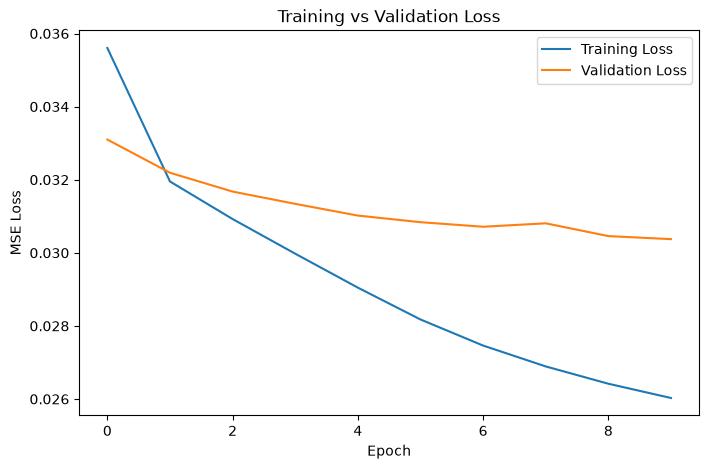

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.show()

# Visualize Mean Absolute Error

Compare the training and validation Mean Absolute Error (MAE) across epochs.

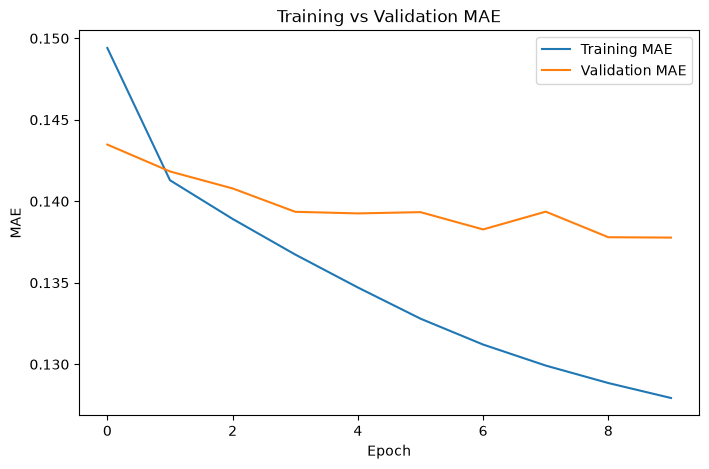

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.show()

# Evaluate the Model

Evaluate the trained model on the held-out test dataset.

In [62]:
loss, mae, rmse = model.evaluate(
    [X_user_test, X_movie_test],
    y_test,
    verbose=0
)

print(f"Test Loss : {loss:.4f}")
print(f"Test MAE  : {mae:.4f}")
print(f"Test RMSE : {rmse:.4f}")

Test Loss : 0.0304
Test MAE  : 0.1378
Test RMSE : 0.1743


# Conclusions

## What We Accomplished

- Built a Two-Tower Neural Network using TensorFlow and Keras.
- Learned user and movie embeddings from interaction data.
- Applied L2 normalization to the learned representations.
- Computed user-movie similarity using the dot product.
- Successfully trained the model on the MovieLens 1M dataset.
- Evaluated the model using Mean Squared Error (MSE) and Mean Absolute Error (MAE).

## Next Steps

In the next notebook, we will:

- Generate personalized movie recommendations for users.
- Retrieve the top-K most relevant movies.
- Save the trained model.
- Build an inference pipeline for deployment.

# Create Artifacts Directory

Create a directory to store the trained model and preprocessing artifacts required for inference and deployment.

In [63]:
import os

os.makedirs("../artifacts", exist_ok=True)

print("Artifacts directory is ready.")

Artifacts directory is ready.


# Save the Trained Model

Save the trained Two-Tower model in the native Keras format for future inference and deployment.

In [64]:
model.save("../artifacts/two_tower_model.keras")

print("Model saved successfully.")

Model saved successfully.


# Save Mapping Dictionaries

Store the user and movie index mappings so that the same encoding can be used during inference.

In [65]:
import pickle

# Reverse mappings
index_to_user = {v: k for k, v in user_to_index.items()}
index_to_movie = {v: k for k, v in movie_to_index.items()}

# Save all mappings
with open("../artifacts/user_to_index.pkl", "wb") as f:
    pickle.dump(user_to_index, f)

with open("../artifacts/movie_to_index.pkl", "wb") as f:
    pickle.dump(movie_to_index, f)

with open("../artifacts/index_to_user.pkl", "wb") as f:
    pickle.dump(index_to_user, f)

with open("../artifacts/index_to_movie.pkl", "wb") as f:
    pickle.dump(index_to_movie, f)

print("Mapping dictionaries saved successfully.")

Mapping dictionaries saved successfully.


# Verify Saved Artifacts

Verify that all required files have been saved successfully.

In [66]:
os.listdir("../artifacts")

['index_to_movie.pkl',
 'index_to_user.pkl',
 'movie_to_index.pkl',
 'two_tower_model.keras',
 'user_to_index.pkl']